In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('./data/pet_adoption_data.csv')

In [14]:
df.describe(include='all')

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,2007.000000,2007,2007,2007.000000,2007,2007,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
unique,NaN,4,7,NaN,5,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Dog,Rabbit,NaN,White,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,522,493,NaN,420,714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1503.000000,NaN,NaN,92.279522,NaN,NaN,15.705776,0.701046,0.196313,43.974091,249.142003,0.301943,0.328351
std,579.515315,NaN,NaN,52.148363,NaN,NaN,8.327749,0.457914,0.397307,25.740253,142.887040,0.459215,0.469730
min,500.000000,NaN,NaN,1.000000,NaN,NaN,1.018198,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1001.500000,NaN,NaN,48.000000,NaN,NaN,8.730396,0.000000,0.000000,21.000000,127.000000,0.000000,0.000000
50%,1503.000000,NaN,NaN,94.000000,NaN,NaN,15.925416,1.000000,0.000000,45.000000,242.000000,0.000000,0.000000
75%,2004.500000,NaN,NaN,138.000000,NaN,NaN,22.737180,1.000000,0.000000,66.000000,375.000000,1.000000,1.000000


In [15]:
df.info()

df = df.drop(columns=['PetID'])

<class 'pandas.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   str    
 2   Breed               2007 non-null   str    
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   str    
 5   Size                2007 non-null   str    
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 204.0 KB


zbior danych kompletny nie musimy inputowac

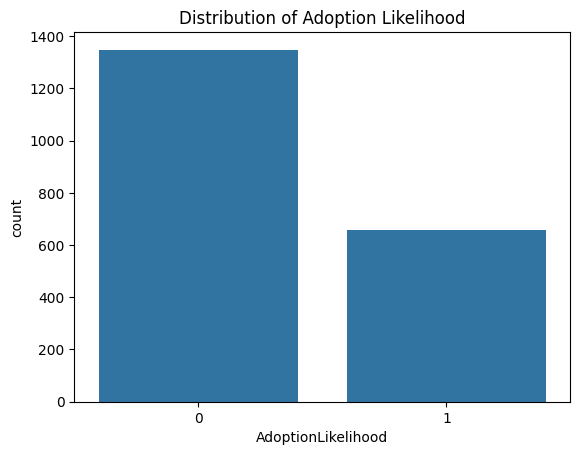

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='AdoptionLikelihood', data=df)
plt.title('Distribution of Adoption Likelihood')
plt.show()

In [17]:


def symulacja_budzetu(y_true, y_proba, budzet=200, koszt_reklamy=10):
    """
    Funkcja oceniająca kampanię na podstawie przewidzianych prawdopodobieństw.
    
    Parametry:
    y_true - rzeczywiste etykiety (1 = szansa na adopcję)
    y_proba - prawdopodobieństwa klasy 1 wyznaczone przez model
    budzet - całkowity budżet (zgodnie z zadaniem 200$)
    koszt_reklamy - koszt jednej reklamy (10$)
    
    Zwraca:
    Oczekiwaną, łączną liczbę zaadoptowanych zwierząt.

    
    """
    if y_proba.ndim == 2:
        y_proba = y_proba[:, 1]

    max_reklam = budzet // koszt_reklamy 
    
    wyniki = pd.DataFrame({'y_true': y_true, 'proba': y_proba})
    wyniki_posortowane = wyniki.sort_values(by='proba', ascending=False)
    
    wybrane = wyniki_posortowane.head(max_reklam)
    
    tp = (wybrane['y_true'] == 1).sum()
    fp = (wybrane['y_true'] == 0).sum()
    
    oczekiwana_liczba_adopcji = (tp * 0.70) + (fp * 0.10)
    
    return oczekiwana_liczba_adopcji

In [18]:
y = df['AdoptionLikelihood']
X = df.drop('AdoptionLikelihood', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--POROWNANIE MODELI --


In [19]:
import joblib

model_NB = joblib.load('NB_shelter_model.pkl')

NaiveBayes - ilosc zwierzat: 12.80


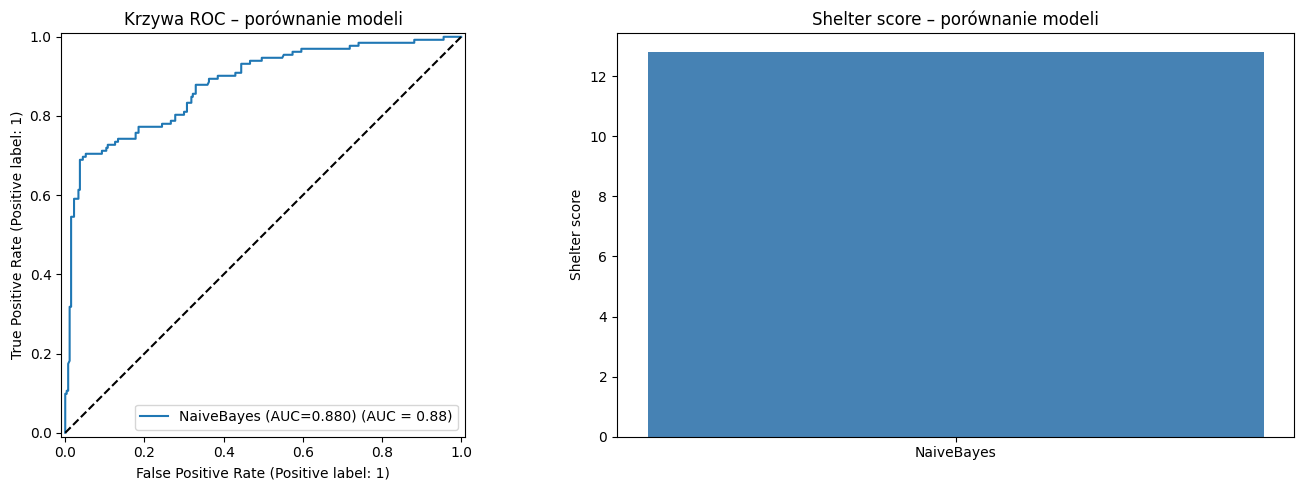

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay, roc_auc_score, precision_score

modele = {
    'NaiveBayes': model_NB,
    # 'Model1': model1,
    # 'Model2': model2,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nazwa, model in modele.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    print(f"{nazwa} - ilosc zwierzat: {symulacja_budzetu(y_test, y_prob):.2f}")
    # print(f"{nazwa} - precision: {precision_score(y_test, y_pred):.3f}")
    
    # ROC
    RocCurveDisplay.from_predictions(y_test, y_prob,
                                     name=f'{nazwa} (AUC={roc_auc_score(y_test, y_prob):.3f})',
                                     ax=axes[0])

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Krzywa ROC – porównanie modeli')

# porównanie shelter score jako bar chart
scores = {nazwa: symulacja_budzetu(y_test, model.predict_proba(X_test)[:, 1]) 
          for nazwa, model in modele.items()}
axes[1].bar(scores.keys(), scores.values(), color=['steelblue', 'darkorange', 'green'])
axes[1].set_title('Shelter score – porównanie modeli')
axes[1].set_ylabel('Shelter score')

plt.tight_layout()
plt.show()

In [21]:

def przewidaj_adopcje(dane: dict, model, nazwa: str) -> float:
    probka = pd.DataFrame([dane])
    prawdopodobienstwo = model.predict_proba(probka)[0, 1]
    decyzja = "TAK" if prawdopodobienstwo > 0.5 else "NIE"
    
    print(f"[{nazwa}] Prawdopodobieństwo adopcji: {prawdopodobienstwo:.2%}")
    print(f"[{nazwa}] Czy warto reklamować: {decyzja}")
    
    return prawdopodobienstwo

Próbka


In [22]:
nowe_zwierze = {
    'PetType': 'Dog',
    'Breed': 'Labrador',
    'Color': 'Black',
    'Size': 'Large',
    'AgeMonths': 24,
    'WeightKg': 30.0,
    'AdoptionFee': 100,
    'TimeInShelterDays': 14,
    'Vaccinated': 1,
    'HealthCondition': 0,
    'PreviousOwner': 0
}

In [23]:
przewidaj_adopcje(nowe_zwierze, model_NB, 'NaiveBayes')

[NaiveBayes] Prawdopodobieństwo adopcji: 87.65%
[NaiveBayes] Czy warto reklamować: TAK


np.float64(0.876509412203416)